
8


/tmp/ipykernel_127593/2522722037.py:142: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colormap=cm.get_cmap("Spectral")
/home/konrad/.local/pipx/venvs/jupyterlab/lib/python3.11/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/konrad/.local/pipx/venvs/jupyterlab/lib/python3.11/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


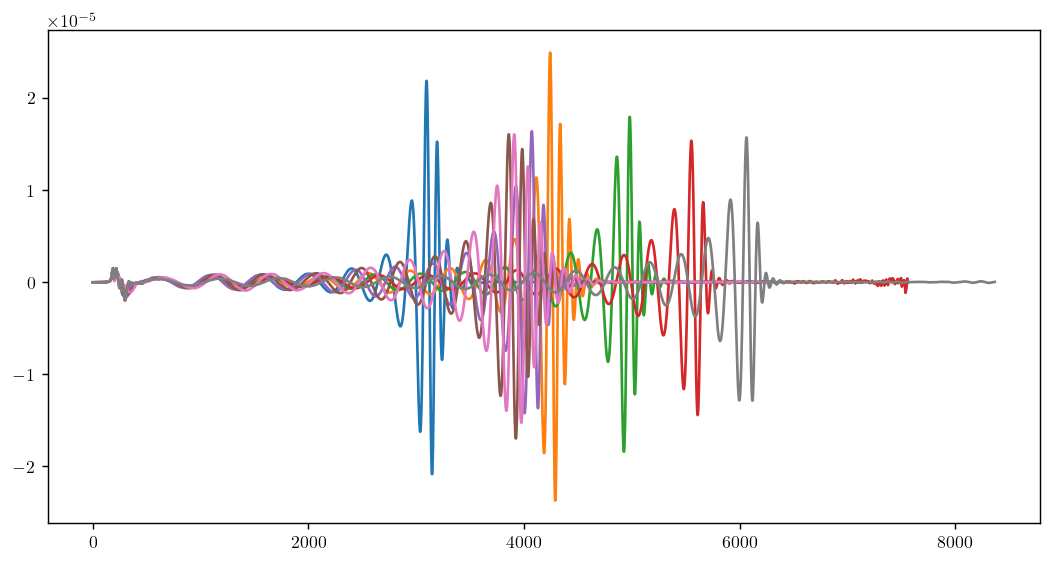

In [1]:
import os.path
import scipy as scp
import numpy as np, sys, math, itertools, argparse
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.ticker import NullFormatter
from kuibit.simdir import SimDir, load_SimDir
from kuibit.grid_data import UniformGrid, UniformGridData
from kuibit.timeseries import TimeSeries, remove_duplicated_iters
from kuibit import grid_data as gd
from kuibit import grid_data_utils as gdu
from kuibit import series
from matplotlib.colors import LogNorm
from matplotlib import ticker, cm
from matplotlib.ticker import LogFormatter, FixedLocator
import cmasher as cmr 
from numpy.ma import masked_array
from matplotlib.gridspec import GridSpec
from matplotlib.collections import PatchCollection
from kuibit.frequencyseries import FrequencySeries


plt.rcParams.update({
   # 'figure.figsize'    : [6.0, 6.0],
    'text.usetex'       : True,
    'font.family'       : "serif",
    'font.serif'        : "cm",
})

mpl.rcParams['savefig.dpi']=128             
#mpl.rcParams['figure.subplot.bottom']=.125   


# nuclear saturation density in units of [1/MSUN^2]
NuclearSaturationDensity = 4.36592 * np.power(10.0,-4)
MpcToLMsol= 2.089152052322275e+19

def format_tex(float_number):
    exponent = np.floor(np.log10(float_number))
    mantissa = float_number/10**exponent
    mantissa_format = str(mantissa)[0:3]
    #return r"${0}\times10^{{{1}}}$"\
    #       .format(mantissa_format, str(int(exponent)))
    return r"$10^{{{1}}}$"           .format(mantissa_format, str(int(exponent)))

def format_tex_with_front(float_number):
    exponent = np.floor(np.log10(float_number))
    mantissa = float_number/10**exponent
    mantissa_format = str(mantissa)[0:3]
    return r"${0}\times10^{{{1}}}$"           .format(mantissa_format, str(int(exponent)))

def find_nearest_idx(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx
def lighten_color(color, amount=0.5):
    """
    Lightens the given color by multiplying (1-luminosity) by the given amount.
    Input can be matplotlib color string, hex string, or RGB tuple.

    Examples:
    >> lighten_color('g', 0.3)
    >> lighten_color('#F034A3', 0.6)
    >> lighten_color((.3,.55,.1), 0.5)
    """
    import matplotlib.colors as mc
    import colorsys
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], 1 - amount * (1 - c[1]), c[2])


"""
=========  set the directory for the simulation =========
"""

dir="./CollectData/"

rhoETtonb = 2314.995851960494 #unit.urho/unit.BaryonMassgr/(unit.invFmToInvCm**3.)


sim_to_title =   {
    "BHNS_VQCD_q4_chiBH_0_Mtot_7_Z4c_eta_MB_R0_times4" : r"$\chi_{\rm BH}=0.0, q^{-1}=4$",
    "BHNS_VQCD_q4_chiBH_0.4_Mtot_7_Z4c_eta_MB_R0_times4" : r"$\chi_{\rm BH}=0.4, q^{-1} =4 $",
    "BHNS_DD2_q4_chiBH_0.6_Mtot_7_Z4c_eta_MB_R0_times5.6_alphaN_1_kappa0.02_CFL_0.4" : r"$\chi_{\rm BH}=0.6, q^{-1}=4$",
    "BHNS_DD2_q4_chiBH_0.8_Mtot_7_Z4c_joined" : r"$\chi_{\rm BH}=0.8, q^{-1} =4 $",
    "BHNS_DD2_q5_chiBH_0.8_Mtot_8.4_Z4c_eta_MB_R0_times5.6_alphaN_1_kappa0.02_CFL_0.4" : r"$\chi_{\rm BH}=0.8, q^{-1}=5$",
    "BHNS_DD2_q6_chiBH_0.8_Mtot_9.8_BSSN_fullevol" : r"$\chi_{\rm BH}=0.8, q^{-1}=6$",
    #"BHNS_DD2_q7_chiBH_0.8_Mtot_11.2_Z4c" : r"$\chi_{\rm BH}=0.8, q^{-1}=7$",
    "BHNS_DD2_q7_chiBH_0.8_Mtot_11.2_BSSN_fullevol" : r"$\chi_{\rm BH}=0.8, q^{-1}=7$",
    "BHNS_DD2_q4_chiBH_0.8_Mtot_7_Z4c_eta_MB_R0_times5.6_alphaN_1_kappa0.02_CFL_0.4_ECC_RED_MANUAL_2" : r"$\chi_{\rm BH} = 0.8, q^{-1}=4$, ecc. red.",
                    }
if(True):
    sim_to_title={
         "BHNS_VQCD_q4_chiBH_0_Mtot_7_Z4c_eta_MB_R0_times4" : r"\texttt{Q4.chi0.0}",
         "BHNS_VQCD_q4_chiBH_0.4_Mtot_7_Z4c_eta_MB_R0_times4" : r"\texttt{Q4.chi0.4}",
         "BHNS_DD2_q4_chiBH_0.6_Mtot_7_Z4c_eta_MB_R0_times5.6_alphaN_1_kappa0.02_CFL_0.4" : r"\texttt{Q4.chi0.6}",
         "BHNS_DD2_q4_chiBH_0.8_Mtot_7_Z4c_joined" : r"\texttt{Q4.chi0.8}",
         "BHNS_DD2_q5_chiBH_0.8_Mtot_8.4_Z4c_eta_MB_R0_times5.6_alphaN_1_kappa0.02_CFL_0.4" : r"\texttt{Q5.chi0.8}",
         "BHNS_DD2_q6_chiBH_0.8_Mtot_9.8_BSSN_fullevol" : r"\texttt{Q6.chi0.8}",
         "BHNS_DD2_q7_chiBH_0.8_Mtot_11.2_BSSN_fullevol" : r"\texttt{Q7.chi0.8}",
         "BHNS_DD2_q4_chiBH_0.8_Mtot_7_Z4c_eta_MB_R0_times5.6_alphaN_1_kappa0.02_CFL_0.4_ECC_RED_MANUAL_2" : r"\texttt{Q4.chi0.8.er}",

    }
    print("")


sim_to_mtot={
    "BHNS_VQCD_q4_chiBH_0_Mtot_7_Z4c_eta_MB_R0_times4" : 7,
    "BHNS_VQCD_q4_chiBH_0.4_Mtot_7_Z4c_eta_MB_R0_times4" : 7,
    "BHNS_DD2_q4_chiBH_0.6_Mtot_7_Z4c_eta_MB_R0_times5.6_alphaN_1_kappa0.02_CFL_0.4" : 7,
    "BHNS_DD2_q4_chiBH_0.8_Mtot_7_Z4c_joined" : 7,

    "BHNS_DD2_q5_chiBH_0.8_Mtot_8.4_Z4c_eta_MB_R0_times5.6_alphaN_1_kappa0.02_CFL_0.4" : 8.4,
    "BHNS_DD2_q6_chiBH_0.8_Mtot_9.8_BSSN_fullevol" : 9.8,
    "BHNS_DD2_q7_chiBH_0.8_Mtot_11.2_BSSN_fullevol" : 11.2,
    "BHNS_DD2_q4_chiBH_0.8_Mtot_7_Z4c_eta_MB_R0_times5.6_alphaN_1_kappa0.02_CFL_0.4_ECC_RED_MANUAL_2": 7.0,
    }

sim_to_color={
    "BHNS_DD2_q4_chiBH_0.6_Mtot_7_Z4c_eta_MB_R0_times5.6_alphaN_1_kappa0.02_CFL_0.4" : "forestgreen",
       "BHNS_VQCD_q4_chiBH_0_Mtot_7_Z4c_eta_MB_R0_times4" : "firebrick",
    "BHNS_VQCD_q4_chiBH_0.4_Mtot_7_Z4c_eta_MB_R0_times4" : "darkorange",
       "BHNS_DD2_q5_chiBH_0.8_Mtot_8.4_Z4c_eta_MB_R0_times5.6_alphaN_1_kappa0.02_CFL_0.4" : "firebrick",
        "BHNS_DD2_q4_chiBH_0.8_Mtot_7_Z4c_joined" : "royalblue",
    
   # "BHNS_DD2_q5_chiBH_0.8_Mtot_7_Z4c_eta_MB_R0_times5.6_alphaN_1_kappa0.02_CFL_0.4" : "slategray",
    "BHNS_DD2_q6_chiBH_0.8_Mtot_9.8_BSSN_fullevol" : "blueviolet" ,#"darkorange",
    "BHNS_DD2_q7_chiBH_0.8_Mtot_11.2_BSSN_fullevol" : "purple",
    
    "BHNS_DD2_q4_chiBH_0.8_Mtot_7_Z4c_eta_MB_R0_times5.6_alphaN_1_kappa0.02_CFL_0.4_ECC_RED_MANUAL_2": "royalblue",
}

ColorScheme=0

if(ColorScheme==0):
    colormap=cm.get_cmap("Spectral")
    colormap_numbers=[0.00,0.14,0.26,0.36,
                      0.68,0.81,0.99,0.38]
    counter=0
    print(len(list(sim_to_color.keys())))
    for key in sim_to_title.keys():
        sim_to_color[key] = colormap(colormap_numbers[counter])
        counter+=1
    
if(ColorScheme==1):
    colormap=cm.get_cmap("rainbow")
    colormap_numbers=[0.00,0.14,0.26,0.36,
                      0.68,0.81,0.99,0.38]
    counter=0
    print(len(list(sim_to_color.keys())))
    for key in sim_to_title.keys():
        sim_to_color[key] = colormap(colormap_numbers[counter])
        counter+=1

if(ColorScheme==2):
    cm1=cm.get_cmap("Reds")
    cm2=cm.get_cmap("Purples")
    sim_to_color={
    "BHNS_VQCD_q4_chiBH_0_Mtot_7_Z4c_eta_MB_R0_times4" : cm1(0.15),
    "BHNS_VQCD_q4_chiBH_0.4_Mtot_7_Z4c_eta_MB_R0_times4" : cm1(0.4),
    "BHNS_DD2_q4_chiBH_0.6_Mtot_7_Z4c_eta_MB_R0_times5.6_alphaN_1_kappa0.02_CFL_0.4" : cm1(0.7),
    "BHNS_DD2_q4_chiBH_0.8_Mtot_7_Z4c_joined" : cm1(0.9),
    
    "BHNS_DD2_q5_chiBH_0.8_Mtot_8.4_Z4c_eta_MB_R0_times5.6_alphaN_1_kappa0.02_CFL_0.4" : cm2(0.4),
    "BHNS_DD2_q6_chiBH_0.8_Mtot_9.8_BSSN_fullevol" : cm2(0.7),#"darkorange",
    "BHNS_DD2_q7_chiBH_0.8_Mtot_11.2_BSSN_fullevol" : cm2(0.9),
    
    "BHNS_DD2_q4_chiBH_0.8_Mtot_7_Z4c_eta_MB_R0_times5.6_alphaN_1_kappa0.02_CFL_0.4_ECC_RED_MANUAL_2": cm1(0.9),
    }

sim_to_tmer_ms={key : None for key in sim_to_title
               }

#gomega=0.0088197349422971666
# +0.01007 for Mtot = 2.85
# +0.01051  for Mtot = 3.2 
# therefe
gomega=0.005

# orbital period
T=2.*np.pi/gomega
# distance in Msun of detector of GW extraction
dist=200
tMsolTomsec=0.00493
fig, ax = plt.subplots(figsize=(10,5), dpi=128)


for sim in sim_to_title.keys():
    sim_dir= SimDir(dir+sim)

    
    # loading strain data of dominant l=m=2 mode
    #strain=sim_dir.gws[dist].get_strain_lm(2,2,T,0.1,window_function='tukey',trim_ends=True)
    psi4=sim_dir.gws[dist].get_psi4_lm(2,2)#,0.1,window_function='tukey',trim_ends=True)
    
    # extracting ++ and xx polarization
    psi4pp=psi4.real().y
    psi4xx=-psi4.imag().y
    
    # locating maximum of GW amplitude
    amp=list(np.sqrt(psi4pp[:]**2+psi4xx[:]**2))
    # max_amp=max(amp)
    # i_max=amp.index(max_amp)
    time=psi4.real().t
    # tmerge=time[i_max]
    
    # converting time in ms, subtracting merger time and adding distance from GW extraction 
    #tms=(time-tmerge+dist)*tMsolTomsec

    #tmerge=tmerge-dist

    ax.plot(psi4.t, psi4.y)


           

In [2]:
gomega=0.008

# orbital period
T=2.*np.pi/gomega
# distance in Msun of detector of GW extraction
dist=600
#dist=600

tMsolTomsec=0.00493
#fig_aux, ax_aux = plt.subplots(figsize=(10,5),dpi=128)
# orbital velocity from initial data
iters_to_merger_largest=-20
iters_to_merger_smallest=100000
#    "BHNS_VQCD_q4_chiBH_0.8_Mtot_7_Z4c_eta_MB_R0_times4_joined" : r"$\chi_{\rm BH}=0.8$",

sim_to_strain={key : None for key in sim_to_title.keys()}



counter=0
for sim in sim_to_title.keys():
    sim_dir= SimDir(dir+sim)
    
    # loading strain data of dominant l=m=2 mode
    strain=sim_dir.gws[dist].get_strain_lm(2,2,T,0.05,window_function='tukey',trim_ends=False)
    #sim_to_tmer_ms[sim]=strain.x_at_abs_maximum_y()*tMsolTomsec
    #print(sim, "t_mer = ", sim_to_tmer_ms[sim], "ms")
    #strain.align_at_maximum()
    # extracting ++ and xx polarization
    # rescaling to 40 Mpc
    
    # by default, the strain in kuibit is given as r*(h_+ - i h_x),
    # rescaling of the strain is : r_1 / r_2 
    
    hpp=strain.real().y  /  (40. * MpcToLMsol) * 1e21
    hxx=-strain.imag().y /  (40. * MpcToLMsol) * 1e21

    
    # hpp=strain.real().y  /  (40. * MpcToLMsol) 
    # hxx=-strain.imag().y /  (40. * MpcToLMsol) 

    
    # locating maximum of GW amplitude
    amp=list(np.sqrt(hpp[:]**2+hxx[:]**2))
    max_amp=max(amp)
    i_max=amp.index(max_amp)
    time=strain.real().t
    tmerge=time[i_max]
    
    # converting time in ms, subtracting merger time and adding distance from GW extraction 
    #tms=(time-tmerge+dist)*tMsolTomsec
    tms=(time-tmerge+dist)*tMsolTomsec

    tmerge=tmerge-dist
    sim_to_strain[sim]=strain
    

In [3]:
N_increase_f_resolution=1
savgol_window_size=11
savgol_window_order=5
msun_in_km=1.477  # in km
pc_in_km = 3.08567758 * 10**13 #in km
pc_in_msun=pc_in_km/msun_in_km
mpc40=40*pc_in_msun


# effective strain as done in PostCactus gw_utils
def h_eff(strain, polarization="both", truncate_inspiral=False, end=None):
    from scipy import signal
    from kuibit.frequencyseries import FrequencySeries
    ts = strain.regular_resampled()
    if truncate_inspiral:
    # sets t=0 to strain max    
        ts.align_at_maximum()
    # clips all data up to t=0
        ts.clip(init=0)

    if end != None:
        ts.clip(end=end)

    # We extract the plus and cross components of the strain
    # Note: for an unaltered Kuibit strain, this will in reality be
    # r * hp, r * hc respectively
    hp = ts.real()
    hc = -ts.imag()
  
    # Then, we take the Fourier transform.
    # By extracting hp and hc seperately we obtain
    # the real signal only in the positive frequency space
    hp_fft = hp.to_FrequencySeries()
    hc_fft = hc.to_FrequencySeries()

    # Finally, we can compute the effective strain amplitude 
    # power spectral density akin to [Eq (8-9) in 1604.00246].
    # For a full discussion, see https://github.com/Sbozzolo/kuibit/pull/27
    h_eff = hp_fft
    
    print("Doing polarization: ", polarization)

    if(polarization=="+"):
        h_eff.fft = h_eff.fft = h_eff.f * np.sqrt(
                 (hp_fft.amp**2. ) / 2.0
                )

    elif(polarization=="x"):
        h_eff.fft = h_eff.fft = h_eff.f * np.sqrt(
                 (hc_fft.amp**2. ) / 2.0
                )
    elif(polarization=="both"):
        h_eff.fft = h_eff.f * np.sqrt(
        (hp_fft.amp**2. + hc_fft.amp**2.) / 2.0
          )
    
    else:
        print("YOU MUST CHOOSE POLARIZATION!")

    return h_eff  

'''
    PSD computed in the same fashion as Jen's
    fmin/fmax = in [kHz]
'''

def return_psd(strain22, strain21, polarization, interpolation, filtering,
               savgol_window_size, savgol_window_order, smoothing_at_the_end,
               fmin=0.5, fmax=5.2, fmer=None, tmax=None):
    from kuibit.frequencyseries import FrequencySeries
    
    total_strain_22 = strain22.copy()
    total_strain_21 = strain21.copy()

  # convert to ms
    total_strain_22.t = total_strain_22.t * 1e3
    total_strain_21.t = total_strain_21.t * 1e3

    
  # Get full PSD
    heff_22 = h_eff(total_strain_22, polarization, end=tmax)
    heff_21 = h_eff(total_strain_21, polarization, end=tmax)
    
    # Get PSD from merger to simulation end time
    heff_22_sub = h_eff(total_strain_22, polarization, truncate_inspiral=True, end=tmax)
    
    t_after_merg=total_strain_22.t[-1] - total_strain_22.x_at_abs_maximum_y()
    t_before_merg=(total_strain_22.t[-1]-total_strain_22.t[0])-t_after_merg
    
    #print("Signal duration (not necessarily meaning the signal lifetime(e.g. collapse) is equal to this number) after the merger: ", t_after_merg)
          
    #part of the h_21 strain AFTER the merger (inspiral truncated)
    total_strain_21_sub=copy.deepcopy(total_strain_21)
    total_strain_21_sub.crop(t_before_merg,total_strain_21.t[-1])
    # this is PSD from h_21_truncated_inspiral!
    heff_21_sub=h_eff(total_strain_21_sub, polarization, end=tmax)

    #high and low frequency pass 
    for heff in [heff_21_sub,heff_22_sub, heff_21, heff_22]:
        heff=heff.high_passed(fmin)
        heff=heff.low_passed(fmax)
            

  # frequency interpolation range
    f_interp = np.linspace(np.max([heff_21_sub.f[1],
                                   heff_22_sub.f[1],
                                   heff_22.f[1],
                                   heff_21.f[1]]
                                   #fmin],
                                 ), 
                           # fmin
                            fmax, num=len(heff_22.f)*N_increase_f_resolution)
    #savgol filtering
    
    if(filtering=="savgol"):
        heff_21_sub.savgol_smooth(savgol_window_size,savgol_window_order)
        heff_22_sub.savgol_smooth(savgol_window_size,savgol_window_order)
        heff_21.savgol_smooth(savgol_window_size,savgol_window_order)
        heff_22.savgol_smooth(savgol_window_size,savgol_window_order)
        
    elif(filtering=="moving_avg"):
        from scipy.ndimage import uniform_filter1d
        moving_avg_size=5
        heff_21_sub.fft=uniform_filter1d(heff_21_sub.fft, size=moving_avg_size)
        heff_21.fft=uniform_filter1d(heff_21.fft, size=moving_avg_size)
        heff_22_sub.fft=uniform_filter1d(heff_22_sub.fft, size=moving_avg_size)
        heff_22.fft=uniform_filter1d(heff_22.fft, size=moving_avg_size)

    if(interpolation=='resample'):
        #print("Simple resampling")
        #print("Resampling, not piecewise constant")
        heff_21_sub.resample(f_interp, piecewise_constant=False)
        heff_22_sub.resample(f_interp, piecewise_constant=False)
        heff_21.resample(f_interp, piecewise_constant=False)
        heff_22.resample(f_interp, piecewise_constant=False)
    # resampling in f_interp
    if(interpolation=='resample_pconst'):
        #print("Resampling, piecewise constant")
        heff_21_sub.resample(f_interp, piecewise_constant=True)
        heff_22_sub.resample(f_interp, piecewise_constant=True)
        heff_21.resample(f_interp, piecewise_constant=True)
        heff_22.resample(f_interp, piecewise_constant=True)
    
    # or spline interpolation in f_interp
    elif(interpolation=='spline'):
        heff_21_sub=FrequencySeries(f_interp,heff_21_sub.evaluate_with_spline(f_interp))
        heff_22_sub=FrequencySeries(f_interp,heff_22_sub.evaluate_with_spline(f_interp))
        heff_21    =FrequencySeries(f_interp,heff_21.evaluate_with_spline(f_interp))
        heff_22    =FrequencySeries(f_interp,heff_22.evaluate_with_spline(f_interp) )

    else:
         print("Not doing resampling nor spline interpolation")
        
        
    if(smoothing_at_the_end):
        print("Smoothing at the end")
        heff_21_sub=heff_21_sub.savgol_smoothed(201,2)
        heff_22_sub=heff_22_sub.savgol_smoothed(201,2)
        heff_21=heff_21.savgol_smoothed(201,2)
        heff_22=heff_22.savgol_smoothed(201,2)

        
    #scalefac = lambda f: 2. / f * np.sqrt(2. * f / 1.e3) / (40. * unit.MpcToLMsol)
    scalefac = lambda f: 2. / f * np.sqrt(2. * f / 1.e3) / (mpc40)

    
    #initializing PSDs' x-axis (frequency)
    #psd_22_sub_f = psd_21_sub_f = psd_22_f = psd_21_f=f_interp
    
    #initializing PSDs' y-axis (htilde(f)*\sqrt(f) etc...)
    
    psd_22_sub_fft=scalefac(heff_22_sub.f)*heff_22_sub.fft
    psd_21_sub_fft=scalefac(heff_21_sub.f)*heff_21_sub.fft
    psd_22_fft=scalefac(heff_22.f)*heff_22.fft
    psd_21_fft=scalefac(heff_21.f)*heff_21.fft
    

    return (f_interp, psd_22_fft, psd_21_fft, psd_22_sub_fft, psd_21_sub_fft)
    #return (psd_22_f, psd_21_f, psd_22_sub_f,psd_21_Wsub_f,psd_22_fft, psd_21_fft, psd_22_sub_fft, psd_21_sub_fft)
           
    
def return_psd_only22(strain22, polarization, interpolation, filtering,
               savgol_window_size, savgol_window_order, smoothing_at_the_end,
               fmin=0.2, fmax=5.2, fmer=None, tmax=None):
    from kuibit.frequencyseries import FrequencySeries
    
    total_strain_22 = strain22.copy()

  # convert to ms
    total_strain_22.t = total_strain_22.t * 1e3

    
  # Get full PSD
    heff_22 = h_eff(total_strain_22, polarization, end=tmax)
    
    # Get PSD from merger to simulation end time
    heff_22_sub = h_eff(total_strain_22, polarization, truncate_inspiral=True, end=tmax)
    
    t_after_merg=total_strain_22.t[-1] - total_strain_22.x_at_abs_maximum_y()
    t_before_merg=(total_strain_22.t[-1]-total_strain_22.t[0])-t_after_merg
    
    #print("Signal duration (not necessarily meaning the signal lifetime(e.g. collapse) is equal to this number) after the merger: ", t_after_merg)
          

    #high and low frequency pass 
    for heff in [heff_22_sub, heff_22]:
        heff=heff.high_passed(fmin)
        heff=heff.low_passed(fmax)
            

  # frequency interpolation range
    f_interp = np.linspace(np.max([heff_22_sub.f[1],
                                   heff_22.f[1]]                        #fmin],
                                 ), 
                           # fmin
                            fmax, num=len(heff_22.f)*N_increase_f_resolution)
    #savgol filtering
    
    if(filtering=="savgol"):
        heff_22_sub.savgol_smooth(savgol_window_size,savgol_window_order)
        heff_22.savgol_smooth(savgol_window_size,savgol_window_order)
        
    elif(filtering=="moving_avg"):
        from scipy.ndimage import uniform_filter1d
        moving_avg_size=5
        heff_22_sub.fft=uniform_filter1d(heff_22_sub.fft, size=moving_avg_size)
        heff_22.fft=uniform_filter1d(heff_22.fft, size=moving_avg_size)

    if(interpolation=='resample'):
        print("Simple resampling")
        print("Resampling, not piecewise constant")
        heff_22_sub.resample(f_interp, piecewise_constant=False)
        heff_22.resample(f_interp, piecewise_constant=False)
    # resampling in f_interp
    if(interpolation=='resample_pconst'):
        print("Resampling, piecewise constant")
        heff_22_sub.resample(f_interp, piecewise_constant=True)
        heff_22.resample(f_interp, piecewise_constant=True)
    
    # or spline interpolation in f_interp
    elif(interpolation=='spline'):
        heff_22_sub=FrequencySeries(f_interp,heff_22_sub.evaluate_with_spline(f_interp))
        heff_22    =FrequencySeries(f_interp,heff_22.evaluate_with_spline(f_interp) )

    else:
         print("Not doing resampling nor spline interpolation")
        
        
    if(smoothing_at_the_end):
        print("Smoothing at the end")
        heff_22_sub=heff_22_sub.savgol_smoothed(201,2)
        heff_22=heff_22.savgol_smoothed(201,2)

        
    #scalefac = lambda f: 2. / f * np.sqrt(2. * f / 1.e3) / (40. * unit.MpcToLMsol)
    scalefac = lambda f: 2. / f * np.sqrt(2. * f / 1.e3) / (mpc40)

    
    #initializing PSDs' x-axis (frequency)
    #psd_22_sub_f = psd_21_sub_f = psd_22_f = psd_21_f=f_interp
    
    #initializing PSDs' y-axis (htilde(f)*\sqrt(f) etc...)
    
    psd_22_sub_fft=scalefac(heff_22_sub.f)*heff_22_sub.fft
    psd_22_fft=scalefac(heff_22.f)*heff_22.fft
    

    return (f_interp, psd_22_fft, psd_22_sub_fft)
    #return (psd_22_f, psd_21_f, psd_22_sub_f,psd_21_Wsub_f,psd_22_fft, psd_21_fft, psd_22_sub_fft, psd_21_sub_fft)
# Mtot_OmegaISCO_Taniguchi
# 0.10539558550602592 1.083234932254923 1.2746799449186632
def function_ISCO_tanig_MADM_0(comp,qhat):
    A=0.10539558550602592
    B=1.083234932254923
    C=1.2746799449186632
    return A*(1 - B*(1-C*comp**(1/3))/qhat**(0.25))

def function_ISCO_tanig_MADM_0_WithChiBH(comp,qhat,ChiBH):
    return function_ISCO_tanig_MADM_0(comp,qhat)*f_of_ChiBH_qhat_MS(ChiBH,qhat)
    
# Mtot_Omega_ISCO function's best-fit parameters for the ChiBH=0 for EOS_intermediate: 

#    a:  0.03777122 +/- 0.00637011 (16.86%) (init = 0.07)
#    b:  0.56840409 +/- 0.17371817 (30.56%) (init = 0.4)
#    p: -2.02959997 +/- 0.05662810 (2.79%) (init = -0.8)

# def function_ISCO(comp,qhat, MADM_0,a=0.03777122,b=0.56840409,p=-2.02959997):
#     return a*(1/MADM_0)*(1+ b/qhat**(1+p*comp**(1/3)))**(3/2)# + a0 + b0*comp
# def function_ISCO_MADM_0(comp,qhat,a=0.03777122,b=0.56840409,p=-2.02959997):
#     return a*(1+ b/qhat**(1+p*comp**(1/3)))**(3/2)# + a0 + b0*comp

# Mtot_Omega_MS function's best-fit parameters for the ChiBH=0 for EOS_intermediate: 
#     a:  0.30505910 +/- 0.00513508 (1.68%) (init = 0.32)
#     b:  4.49605512 +/- 0.44762083 (9.96%) (init = 0)
#     c: -0.00976210 +/- 0.00188670 (19.33%) (init = 0)

# TD: 0.26096967276939537 1.9115355588532597 -0.009881325806536506

# def function_TD_MADM_0_modified(comp,qhat, a=0.26096967276939537,b=1.9115355588532597,c=-0.009881325806536506):
#     return (a)*(comp**(3/2))*(1+b*comp)*(1+c*qhat)*(1+qhat)*(1+1/(qhat))**(1/2)
    
# def function_TD_modified(comp,qhat, MADM_0,  a=0.26096967276939537,b=1.9115355588532597,c=-0.009881325806536506):
#     return function_TD_MADM_0_modified(comp,qhat,a,b,c)*(1/MADM_0)
    
def function_TD_MADM_0_modified(comp,qhat, boolGam2=False):
    if(boolGam2):
        a=0.33429
        b=-0.21766
        c=-0.002866
    else:
        a=0.26096967276939537
        b=1.9115355588532597
        c=-0.009881325806536506
        
    return (a)*(comp**(3/2))*(1+b*comp)*(1+c*qhat)*(1+qhat)*(1+1/(qhat))**(1/2)
    
def function_TD_modified(comp,qhat, MADM_0, EOSName="inter"):
    if(EOSName=="Gam2"):
        a=0.33429
        b=-0.21766
        c=-0.002866
    elif(EOSName=="inter"):
        a=0.26096967276939537
        b=1.9115355588532597
        c=-0.009881325806536506
    else:
        a=  0.26378671 
        b=  1.82128258
        c= -0.01126586 
    return function_TD_MADM_0_modified(comp,qhat,EOSName)*(1/MADM_0)


# ISCO: 0.10969079343179548 -0.26786361419324145 0.7868984189995946
def function_ISCO_modified(comp,qhat, MADM_0,a=0.10969079343179548,alpha= -0.2678636141932414,beta=0.7868984189995946):
    return (1/MADM_0)*(6**(-3./2.))*(1+a/(qhat**alpha))*(1+a*comp**beta)# + a0 + b0*comp

def function_ISCO_MADM_0_modified(comp,qhat,a=0.10969079343179548,alpha= -0.2678636141932414,beta=0.7868984189995946):
    return (6**(-3./2.))*(1+a/(qhat**alpha))*(1+a*comp**beta)

def function_ISCO_MADM_0_modified_3(comp,qhat,EOSName="inter"):
    if(EOSName=="Gam2"):
        aISCO=0.57464
        alphaISCO=0.44673
        betaISCO=0.67579
    elif(EOSName=="inter"):
        aISCO=0.12576568
        alphaISCO= -0.27657493
        betaISCO= 1.15062643
    else:
        aISCO=     0.04885434 
        alphaISCO= -0.53826840 
        betaISCO=  0.72062738 
        
    return (6**(-3./2.))*(1+aISCO/(qhat**alphaISCO))*(1+aISCO*(1/qhat)*comp**betaISCO)

def function_ISCO_modified_3(comp,qhat, MADM_0, EOSName="inter"):
    if(EOSName=="Gam2"):
        aISCO=0.57464
        alphaISCO=0.44673
        betaISCO=0.67579
    elif(EOSName=="inter"):
        aISCO     =0.12576568
        alphaISCO = -0.27657493
        betaISCO  = 1.15062643
    else:
        aISCO=     0.04885434 
        alphaISCO= -0.53826840 
        betaISCO=  0.72062738 
    return (1/MADM_0)*(6**(-3./2.))*(1+aISCO/(qhat**alphaISCO))*(1+aISCO*(1/qhat)*comp**betaISCO)# + a0 + b0*comp
    
# ISCO spin dependence for a rescaled function; (a, b, c) =  0.45541219599182214 0.8190143648800697 1.0101612954462902
def f_of_ChiBH_ISCO(ChiBH, aa=0.45541219599182214, bb= 0.8190143648800697, cc=1.010161295446290):
    return aa*ChiBH*ChiBH + bb*ChiBH + cc

# MS spin dependence for a rescaled function; (a, b, c) =  -0.014945933829817166 0.05763875568419102 1.000303923279402
def f_of_ChiBH_MS(ChiBH, val, aaa=-0.014945933829817166, bbb=0.05763875568419102 , ccc=1.000303923279402):
    return aaa*ChiBH*ChiBH + bbb*ChiBH + ccc

# [[Variables]]
#     a: -0.01539146 +/- 0.00110270 (7.16%) (init = 0.1)
#     b:  0.00773953 +/- 0.00321133 (41.49%) (init = 0.05)
#     c:  1.00032183 +/- 4.5648e-04 (0.05%) (init = 0.02)
#     d:  0.01006114 +/- 6.3829e-04 (6.34%) (init = 0.002)
# MS (spin,qhat) dependence - the one to be used 
def f_of_ChiBH_qhat_MS(ChiBH, qhat, aaaa=-0.01539146, bbbb=0.00773953, cccc= 1.00032183 , dddd=0.01006114):
    return (aaaa*ChiBH*ChiBH + bbbb*ChiBH + cccc)*(1+ dddd*ChiBH*qhat)

# finally, MS and ISCO predictors with non-zero BH spin:

def function_ISCO_MADM_0_WithChiBH(comp,qhat,ChiBH, EOSName):
    #return function_ISCO_MADM_0_modified(comp,qhat)*f_of_ChiBH_ISCO(ChiBH)
    return function_ISCO_MADM_0_modified_3(comp,qhat,EOSName)*f_of_ChiBH_ISCO(ChiBH)

def function_TD_MADM_0_WithChiBH(comp,qhat,ChiBH,EOSName):
    return function_TD_MADM_0_modified(comp,qhat,EOSName)*f_of_ChiBH_qhat_MS(ChiBH,qhat)
    


In [4]:
CU_time=4.925553195445955e-06
for sim in sim_to_strain.keys():
    sim_to_strain[sim] = sim_to_strain[sim].time_unit_changed(CU_time, inverse=True).copy()

BHNS_VQCD_q4_chiBH_0_Mtot_7_Z4c_eta_MB_R0_times4
Doing polarization:  both
Doing polarization:  both
Simple resampling
Resampling, not piecewise constant
Not doing resampling nor spline interpolation
BHNS_VQCD_q4_chiBH_0.4_Mtot_7_Z4c_eta_MB_R0_times4
Doing polarization:  both
Doing polarization:  both
Simple resampling
Resampling, not piecewise constant
Not doing resampling nor spline interpolation
BHNS_DD2_q4_chiBH_0.6_Mtot_7_Z4c_eta_MB_R0_times5.6_alphaN_1_kappa0.02_CFL_0.4
Doing polarization:  both
Doing polarization:  both
Simple resampling
Resampling, not piecewise constant
Not doing resampling nor spline interpolation
BHNS_DD2_q4_chiBH_0.8_Mtot_7_Z4c_joined
Doing polarization:  both
Doing polarization:  both
Simple resampling
Resampling, not piecewise constant
Not doing resampling nor spline interpolation
BHNS_DD2_q5_chiBH_0.8_Mtot_8.4_Z4c_eta_MB_R0_times5.6_alphaN_1_kappa0.02_CFL_0.4
Doing polarization:  both
Doing polarization:  both
Simple resampling
Resampling, not piecewise 

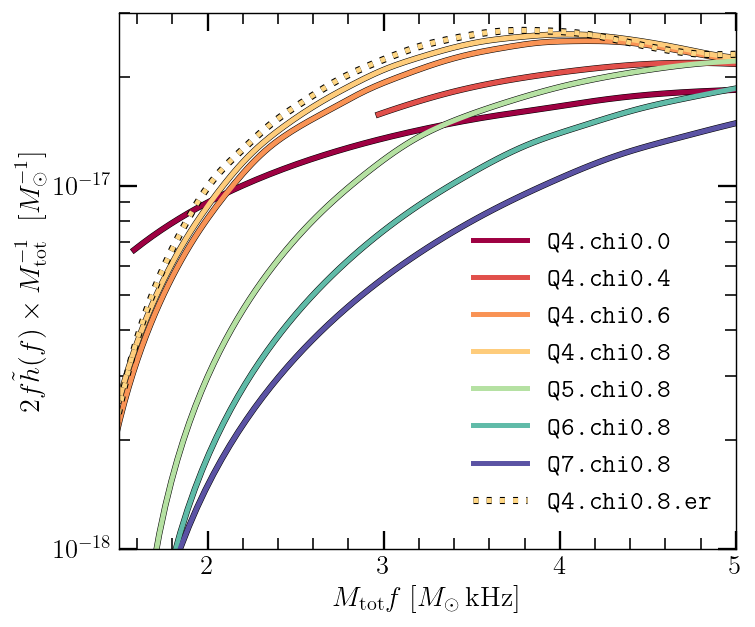

In [22]:
polarization="both"
interpolation="resample"
#filtering="none"
filtering="savgol"
smoothing_at_the_end=False
import matplotlib.patheffects as pe

savgol_window_order=3
savgol_window_size=25


fig, ax=plt.subplots(figsize=(6,5), facecolor='white',dpi=128)


for Nsim, sim in enumerate(sim_to_strain.keys()):
    print(sim)
    f_interp, psd_22, psd_22_sub=return_psd_only22(sim_to_strain[sim],
                                                                 polarization,
                                                                 interpolation,
                                                                 filtering,
                                                                 savgol_window_size,
                                                                 savgol_window_order,
                                                                 smoothing_at_the_end) 
    
    
    # fig_aux, ax_aux=   plt.subplots(figsize=(6,4), facecolor='white', dpi=128)
    # ax_aux.plot(sim_to_strain[sim].t*1000, sim_to_strain[sim].y, color='black', label=r"$h_{+}^{22}$")
    # ax_aux.set_xlabel(r"$t$ [ms]", fontsize=10)
    # ax_aux.set_ylabel(r"$R \;\; h_{+} [M]$, $R=200M_{\odot}$", fontsize=10)
    # plt.legend()
      
    #plt.clf()
    #plt.close("all")
    # fig_aux, ax_aux=   plt.subplots(figsize=(6,4), facecolor='white', dpi=100)
    # ax_aux.set_xlabel(r"$t$ [ms]", fontsize=10)
    # ax_aux.set_ylabel(r"$ \psi_{4,+} $, $R=300M_{\odot}$", fontsize=10)
    # plt.legend()
 
    #print("Savgol filter has a window of size:", (f_interp[savgol_window_size]-f_interp[0]), "kHz")
    
    # if(Nsim>0):
    #     continue  
    if(not sim=="BHNS_DD2_q4_chiBH_0.8_Mtot_7_Z4c_eta_MB_R0_times5.6_alphaN_1_kappa0.02_CFL_0.4_ECC_RED_MANUAL_2"):
    
        ax.semilogy(sim_to_mtot[sim]*f_interp, np.multiply(np.sqrt(f_interp), psd_22)/sim_to_mtot[sim], 
                    color=sim_to_color[sim],
                   label=sim_to_title[sim],linewidth=2.4+0.4,
                   linestyle='solid' if not sim=="BHNS_DD2_q4_chiBH_0.8_Mtot_7_Z4c_eta_MB_R0_times5.6_alphaN_1_kappa0.02_CFL_0.4_ECC_RED_MANUAL_2"
                   else "dotted")
        ax.semilogy(sim_to_mtot[sim]*f_interp, np.multiply(np.sqrt(f_interp), psd_22)/sim_to_mtot[sim], 
                    color='black',
                   #label=sim_to_title[sim],
                    linewidth=3.0+0.4  if not sim=="BHNS_DD2_q4_chiBH_0.8_Mtot_7_Z4c_eta_MB_R0_times5.6_alphaN_1_kappa0.02_CFL_0.4_ECC_RED_MANUAL_2" else 2.0 ,zorder=0.2,
                   linestyle='solid' if not sim=="BHNS_DD2_q4_chiBH_0.8_Mtot_7_Z4c_eta_MB_R0_times5.6_alphaN_1_kappa0.02_CFL_0.4_ECC_RED_MANUAL_2"
                   else "dotted",
                   )
        #ax.semilogy(f_interp, psd_22_sub, color=sim_to_color[sim],
        #           label=sim_to_title[sim])
    else:
        ax.semilogy(sim_to_mtot[sim]*f_interp, np.multiply(np.sqrt(f_interp), psd_22)/sim_to_mtot[sim], 
                    color=sim_to_color[sim],
                   label=sim_to_title[sim],linewidth=2.4+0.4,
                   linestyle='solid' if not sim=="BHNS_DD2_q4_chiBH_0.8_Mtot_7_Z4c_eta_MB_R0_times5.6_alphaN_1_kappa0.02_CFL_0.4_ECC_RED_MANUAL_2"
                   else "dotted",
                    path_effects=[pe.Stroke(linewidth=4., foreground='black'), pe.Normal()]
                   )
        
    psd_22_sub_full=FrequencySeries(f_interp,psd_22_sub)

#ax.set_yticks(
#ax.set_ylabel(r"$2 \sqrt{f} \tilde{h}(f) \, {\rm [Hz^{-1/2}], \; 40 MPc}$",size=12)
#ax.set_ylabel(r"$2 \sqrt{f} \tilde{h}(f) \, {\rm [Hz^{-1/2}]}$",fontsize=14)
#ax.set_ylabel(r"$2 f \tilde{h}(f) $",fontsize=16)
ax.set_ylabel(r"$2 f \tilde{h}(f) \times M_{\rm tot}^{-1} \;\;[M_{\odot}^{-1}]  $",fontsize=16)
ax.set_xlabel(r"$M_{\rm tot}f \; [M_{\odot}\,{\rm{kHz}}]$",fontsize=16)
large_y_ticks=[1e-18,1e-17,1e-16]
small_y_ticks=[i * 1e-18 for i in range(1,10)] +[i * 1e-17 for i in range(1,10)] + [i * 1e-16 for i in range(1,10)]
large_x_ticks=[0,1,2,3,4,5,10,15,20,25]
large_x_ticks=[0,1,2,3,4,5,10,15,20,25]
small_x_ticks=[-2+0.2*i for i in range(60)]
# large_x_ticks=[]
# #ax.set_xticks(large_ticks)
# #ax.set_yticks(y_ticks)
# #     sim_to_ax[sim].set_yticks([-1.5,0,1.5])

ax.set_xticks(large_x_ticks)
ax.set_yticks(large_y_ticks)
ax.xaxis.set_minor_locator(FixedLocator(small_x_ticks))
ax.yaxis.set_minor_locator(FixedLocator(small_y_ticks))

ax.tick_params(bottom=True, top=False, left=True, right=False ) 
ax.tick_params(which='minor', width=0.9, length=6,labelsize=11,direction='in', color="black", bottom=True, top=True, left=True, right=True)                  
ax.tick_params(which='major', width=1.3, length=10,labelsize=15,direction='in', color="black", bottom=True, top=True, left=True, right=True)                  


#ax.set_xlim(0.45,2.0)
ax.set_xlim(1.5,5)
ax.set_ylim(1e-18,3e-17)

ax.legend(loc=4, facecolor='none',edgecolor='none', fontsize=15,
          ncols=1,  bbox_to_anchor=(0.5, 0.02, 0.5, 0.5)
         )

fig.tight_layout()

plt.subplots_adjust(wspace=0.0, 
                    hspace=0.0)

plt.savefig("/home/konrad/tidaldisruption2024_paper/submitted/reports/BHNS_spectra_zoom_in.pdf",dpi=128,bbox_inches='tight')


In [6]:
# 6 0.8 1.1309242327611466 1.1352296889598352
# 6 0.8 1.1581443175087698 1.061139724376538
